In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/sample_submission.csv
/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/train.csv
/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/test.csv


In [2]:
ss = pd.read_csv('/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/sample_submission.csv')
test = pd.read_csv('/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/test.csv')
train = pd.read_csv('/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/train.csv')

In [3]:
train.head()

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


In [4]:
ss.head()

,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e


# null value handling

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7000 non-null   int64  
 1   mushroom_id               7000 non-null   int64  
 2   cap-shape                 7000 non-null   object 
 3   cap-surface               7000 non-null   object 
 4   cap-color                 7000 non-null   object 
 5   bruises                   7000 non-null   object 
 6   number_of_bruises         7000 non-null   int64  
 7   odor                      3764 non-null   object 
 8   gill-attachment           7000 non-null   object 
 9   gill-spacing              7000 non-null   object 
 10  gill-size                 7000 non-null   object 
 11  gill-color                7000 non-null   object 
 12  stalk-shape               7000 non-null   object 
 13  stalk-root                6808 non-null   object 
 14  stalk-su

In [6]:
num_desc = train.drop(columns=['ID','mushroom_id'])
num_desc.describe()

,number_of_bruises,ring-number
count,7000.000000,6964.000000
mean,5.459571,1.080988
std,7.723528,0.272836
min,0.000000,1.000000
25%,0.000000,1.000000
50%,0.000000,1.000000
75%,11.000000,1.000000
max,24.000000,2.000000


In [7]:
train.isnull().sum()

ID                             0
mushroom_id                    0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
number_of_bruises              0
odor                        3236
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                   192
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                   36
ring-type                     36
spore-print-color              0
population                     0
habitat                        0
class                          0
dtype: int64

In [8]:
(train.isnull().sum() / len(train) * 100).round(2)

ID                           0.00
mushroom_id                  0.00
cap-shape                    0.00
cap-surface                  0.00
cap-color                    0.00
bruises                      0.00
number_of_bruises            0.00
odor                        46.23
gill-attachment              0.00
gill-spacing                 0.00
gill-size                    0.00
gill-color                   0.00
stalk-shape                  0.00
stalk-root                   2.74
stalk-surface-above-ring     0.00
stalk-surface-below-ring     0.00
stalk-color-above-ring       0.00
stalk-color-below-ring       0.00
veil-type                    0.00
veil-color                   0.00
ring-number                  0.51
ring-type                    0.51
spore-print-color            0.00
population                   0.00
habitat                      0.00
class                        0.00
dtype: float64

In [9]:
(train.isnull().sum().sum() / (train.shape[0] * train.shape[1]) * 100).round(2)

np.float64(1.92)

In [10]:
print(test.isnull().sum())

ID                            0
mushroom_id                   0
cap-shape                     0
cap-surface                   0
cap-color                     0
bruises                       0
number_of_bruises             0
odor                        292
gill-attachment               0
gill-spacing                  0
gill-size                     0
gill-color                    0
stalk-shape                   0
stalk-root                    0
stalk-surface-above-ring      0
stalk-surface-below-ring      0
stalk-color-above-ring        0
stalk-color-below-ring        0
veil-type                     0
veil-color                    0
ring-number                   0
ring-type                     0
spore-print-color             0
population                    0
habitat                       0
dtype: int64


# duplicate Values - no action needed

In [11]:
# print(train.duplicated(),test.duplicated())
print(train.duplicated().sum(),test.duplicated().sum())

0 0


In [12]:
import seaborn as sns

<Axes: xlabel='class', ylabel='odor'>

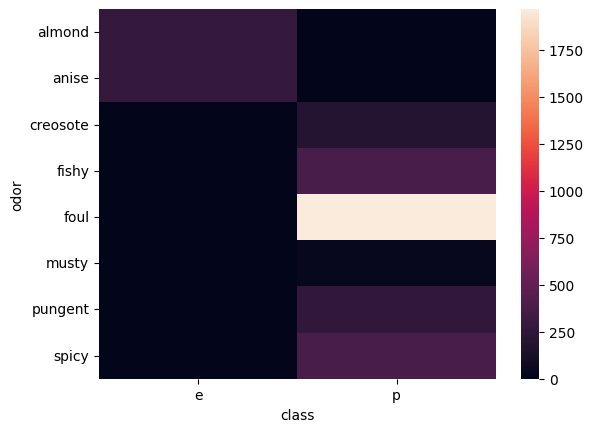

In [13]:
sns.heatmap(pd.crosstab(train['odor'],train['class']))

<Axes: xlabel='class', ylabel='ring-type'>

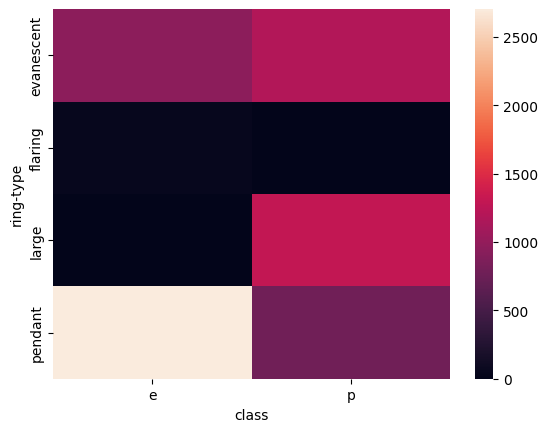

In [14]:
sns.heatmap(pd.crosstab(train['ring-type'],train['class']))

<Axes: xlabel='class', ylabel='cap-surface'>

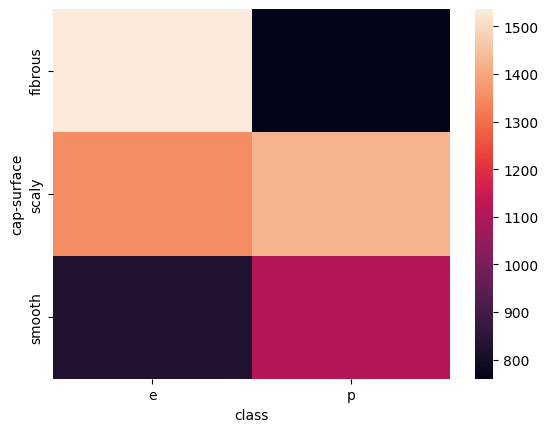

In [15]:
sns.heatmap(pd.crosstab(train['cap-surface'],train['class']))

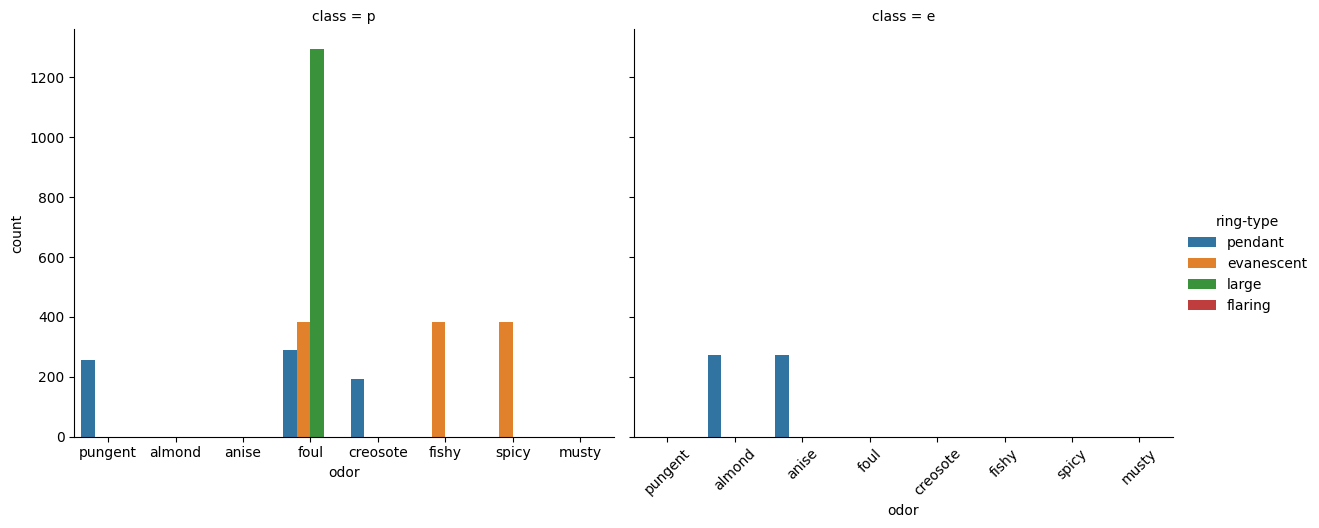

In [16]:
import matplotlib.pyplot as plt
sns.catplot(
    data=train,
    x='odor',
    hue='ring-type',
    col='class',      # <-- THIS is what you want
    kind='count',
    height=5,
    aspect=1.2
)

plt.xticks(rotation=45)
plt.show()

# Missing Not At Random so it is possible for some mashrooms to not have these 

In [17]:
# Drop useless columns first
train = train.drop(['ID', 'mushroom_id'], axis=1)
test = test.drop(['ID', 'mushroom_id'], axis=1)

In [18]:
# Separate target
X = train.drop('class', axis=1)
y = train['class']

# Fill ALL missing values consistently
for col in X.columns:
    X[col] = X[col].fillna('missing')
    test[col] = test[col].fillna('missing')

In [19]:
X.isnull().sum()

cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
number_of_bruises           0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [20]:
test.isnull().sum()

cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
number_of_bruises           0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

# one hot encoding 

In [21]:
# One-hot encoding
X = pd.get_dummies(X)
test = pd.get_dummies(test)

# Align columns (CRITICAL)
X, test = X.align(test, join='left', axis=1, fill_value=0)

In [22]:
print(X.shape)
print(test.shape)
print(X.columns.equals(test.columns))

(7000, 103)
(1124, 103)
True


# train test split 

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# split again using encoded target
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.18, stratify=y_encoded, random_state=42
)

# model building 

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_val)
print("DT Accuracy:", accuracy_score(y_val, dt_pred))

DT Accuracy: 1.0


In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=1,
    colsample_bytree=1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_val)
print("XGB Accuracy:", accuracy_score(y_val, xgb_pred))

XGB Accuracy: 1.0


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
print("RF:", accuracy_score(y_val, rf_pred))

RF: 1.0


In [28]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(n_estimators=300)
lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_val)
print("LGB:", accuracy_score(y_val, lgb_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2696, number of negative: 3044
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 207
[LightGBM] [Info] Number of data points in the train set: 5740, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.469686 -> initscore=-0.121403
[LightGBM] [Info] Start training from score -0.121403
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [29]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(verbose=0)
cat.fit(X_train, y_train)
cat_pred = cat.predict(X_val)
print("CAT:", accuracy_score(y_val, cat_pred))

CAT: 1.0


In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_val)
print("LR:", accuracy_score(y_val, lr_pred))

LR: 1.0


In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_val)
print("KNN:", accuracy_score(y_val, knn_pred))

KNN: 1.0


In [32]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print("Best RF:", rf_random.best_params_)

Best RF: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 10}


In [33]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss'),
    xgb_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

print("Best XGB:", xgb_random.best_params_)

Best XGB: {'subsample': 1, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1}


In [34]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    verbose=0
)

cat.fit(X_train, y_train)

CatBoostClassifier(depth=6, iterations=500, learning_rate=0.1, verbose=0)

# Comparison of model performances

In [35]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results = [
    ["Decision Tree", accuracy_score(y_val, dt_pred), f1_score(y_val, dt_pred)],
    ["Random Forest(hypertuned)", accuracy_score(y_val, rf_pred), f1_score(y_val, rf_pred)],
    ["XGBoost(hypertuned)", accuracy_score(y_val, xgb_pred), f1_score(y_val, xgb_pred)],
    ["LightGBM", accuracy_score(y_val, lgb_pred), f1_score(y_val, lgb_pred)],
    ["CatBoost(hypertuned)", accuracy_score(y_val, cat_pred), f1_score(y_val, cat_pred)],
    ["Logistic Regression", accuracy_score(y_val, lr_pred), f1_score(y_val, lr_pred)],
    ["KNN", accuracy_score(y_val, knn_pred), f1_score(y_val, knn_pred)]
]

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

                       Model  Accuracy  F1 Score
0              Decision Tree       1.0       1.0
1  Random Forest(hypertuned)       1.0       1.0
2        XGBoost(hypertuned)       1.0       1.0
3                   LightGBM       1.0       1.0
4       CatBoost(hypertuned)       1.0       1.0
5        Logistic Regression       1.0       1.0
6                        KNN       1.0       1.0


In [36]:
print(X.shape)
print(test.shape)

(7000, 103)
(1124, 103)


In [37]:
xgb.fit(X, y_encoded)
test_pred = xgb.predict(test)
test_pred = le.inverse_transform(test_pred)

In [38]:
 original_test=pd.read_csv("/kaggle/input/competitions/mlp-kaggle-assignment-2-extended/test.csv")

test_ids = original_test['ID']

In [39]:
import pandas as pd

submission = pd.DataFrame({
    'ID': test_ids,
    'class': test_pred
})

In [40]:
submission.to_csv('submission.csv', index=False)

In [41]:
print(submission.head())

   ID class
0   1     e
1   2     e
2   3     e
3   4     e
4   5     e


In [42]:
submission.shape

(1124, 2)